#### Script to use the hugging face pipeline function. Code ran in google colab

In [1]:
!pip install -q --upgrade huggingface_hub datasets==3.6.0 transformers==4.57.6

In [2]:
import torch
from google.colab import userdata
from huggingface_hub import login
from transformers import pipeline
from diffusers import DiffusionPipeline
from IPython.display import Audio

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
hf_token = userdata.get('hf_token')
login(hf_token, add_to_git_credential=True)

In [4]:
## Sentiment analysis using no model

sentiment_analyzer = pipeline("sentiment-analysis", device="cuda")
result = sentiment_analyzer("Learning about LLM is fun")
print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Device set to use cuda


[{'label': 'POSITIVE', 'score': 0.9998641014099121}]


In [5]:
## using a model

sentiment_model = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", device="cuda")
result = sentiment_model("Today I am learning about using the pipeline function from Huggingface")
print(result)

## Can try other models such as model=FacebookAI/roberta-large-mini

Device set to use cuda


[{'label': '5 stars', 'score': 0.45163846015930176}]


In [6]:
## using multiple inputs

multi_sentiment = pipeline("text-classification", model="FacebookAI/roberta-large-mnli", device="cuda")
result = multi_sentiment(["ChatGPT is awesome", "This CPU is awful"])
print(result)

Some weights of the model checkpoint at FacebookAI/roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda


[{'label': 'NEUTRAL', 'score': 0.7049400210380554}, {'label': 'NEUTRAL', 'score': 0.8328281044960022}]


In [7]:
# Classification of text

classifier = pipeline("zero-shot-classification", device="cuda")
result = classifier("LLMs are useful tools", candidate_labels=["technology", "sports", "politics"])
print(result)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda


{'sequence': 'LLMs are useful tools', 'labels': ['technology', 'sports', 'politics'], 'scores': [0.9670200943946838, 0.018675224855542183, 0.01430468913167715]}


## Image generation

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


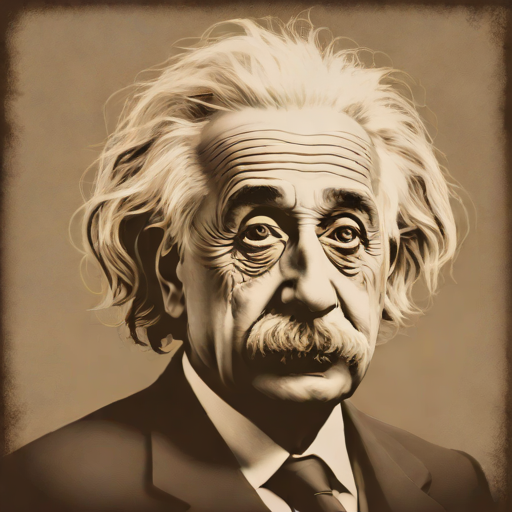

In [8]:
from IPython.display import display
from diffusers import AutoPipelineForText2Image
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipe.to("cuda")
prompt = "Create a portrait of Einstein"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)